# Minimal flow matching in one dimension

This notebook is a compact, self-contained adaptation of Peter Roelants' [Flow Matching: A visual introduction](https://peterroelants.github.io/posts/flow_matching_intro/). It learns to transport samples from a standard Gaussian $\pi_0$ to a bimodal Gaussian mixture $\pi_1$.

Only NumPy, Matplotlib, and PyTorch are required.

In [15]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

NUMPY_SEED = 42
TORCH_SEED = 42 #626
np.random.seed(NUMPY_SEED)
torch.manual_seed(TORCH_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TORCH_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device: {DEVICE}")

PyTorch 2.1.0; device: cuda


## 1. Source and target distributions

The source is $x_0 \sim \mathcal{N}(0,1)$. The target is a weighted mixture of two one-dimensional Gaussians. In a real application, `sample_mixture` would be replaced by samples from a dataset.

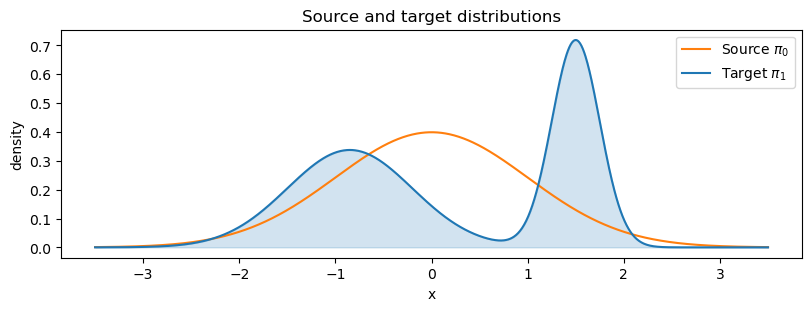

In [16]:
MIXTURE_WEIGHTS = np.array([0.55, 0.45])
MIXTURE_MEANS = np.array([-0.85, 1.50])
MIXTURE_STDS = np.array([0.65, 0.25])
training_rng = np.random.default_rng(NUMPY_SEED)


def normal_pdf(x, mean=0.0, std=1.0):
    """Evaluate a one-dimensional Gaussian density with NumPy."""
    z = (x - mean) / std
    return np.exp(-0.5 * z**2) / (std * np.sqrt(2.0 * np.pi))


def mixture_pdf(x):
    """Evaluate the target Gaussian-mixture density."""
    component_densities = normal_pdf(
        x[None, :], MIXTURE_MEANS[:, None], MIXTURE_STDS[:, None]
    )
    return np.sum(MIXTURE_WEIGHTS[:, None] * component_densities, axis=0)


def sample_mixture(n_samples, rng):
    """Draw samples from the target Gaussian mixture."""
    components = rng.choice(len(MIXTURE_WEIGHTS), size=n_samples, p=MIXTURE_WEIGHTS)
    return rng.normal(MIXTURE_MEANS[components], MIXTURE_STDS[components])


x_grid = np.linspace(-3.5, 3.5, 1000)
fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.plot(x_grid, normal_pdf(x_grid), color="tab:orange", label=r"Source $\pi_0$")
ax.plot(x_grid, mixture_pdf(x_grid), color="tab:blue", label=r"Target $\pi_1$")
ax.fill_between(x_grid, mixture_pdf(x_grid), alpha=0.2, color="tab:blue")
ax.set(xlabel="x", ylabel="density", title="Source and target distributions")
ax.legend();

## 2. Linear flow-matching objective

For independently sampled endpoints $x_0 \sim \pi_0$ and $x_1 \sim \pi_1$, choose $t \sim \mathcal{U}(0,1)$ and interpolate along a straight reference path:

$$x_t = (1-t)x_0 + tx_1, \qquad v_{\mathrm{target}} = \frac{dx_t}{dt} = x_1-x_0.$$

A neural network $v_\theta(x_t,t)$ is trained with mean-squared error:

$$\mathcal{L}(\theta)=\mathbb{E}\left[\lVert v_\theta(x_t,t)-(x_1-x_0)\rVert^2\right].$$

Although each training target comes from one random endpoint pairing, averaging over many pairings teaches the model the marginal velocity field.

In [17]:
def interpolate_linear(x_0, x_1, t):
    return (1.0 - t) * x_0 + t * x_1


def target_velocity(x_0, x_1):
    return x_1 - x_0


class FlowMatchingModel(nn.Module):
    """Small MLP that predicts velocity from position x_t and time t."""

    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1+1, hidden_dim),   # +1 for time embedding
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x_t, t):
        return self.net(torch.cat((x_t, t), dim=-1))


def flow_matching_loss(model, x_0, x_1, t):
    x_t = interpolate_linear(x_0, x_1, t)
    predicted_velocity = model(x_t, t)
    return torch.mean((predicted_velocity - target_velocity(x_0, x_1)) ** 2)

## 3. Train the velocity field

Every optimization step creates a fresh batch of source samples, target samples, and interpolation times. The loss is noisy because the endpoint coupling is sampled independently; its moving average is more informative than any single batch.

In [18]:
N_TRAIN_STEPS = 10000 #3000
BATCH_SIZE = 256
LEARNING_RATE = 1e-3

model = FlowMatchingModel(hidden_dim=64).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
losses = []
model.train()

for step in range(1, N_TRAIN_STEPS + 1):
    # Sample a batch of target and noise samples
    x_1_np = sample_mixture(BATCH_SIZE, training_rng)
    x_1 = torch.as_tensor(x_1_np, dtype=torch.float32, device=DEVICE).unsqueeze(-1)
    x_0 = torch.randn_like(x_1)
    # Sample a random time step for each sample in the batch
    t = torch.rand_like(x_1)

    # Compute the loss
    loss = flow_matching_loss(model, x_0, x_1, t)

    # Backpropagate the loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step == 1 or step % 500 == 0:
        print(f"step {step:4d} | loss {loss.item():.4f}")

step    1 | loss 2.4506
step  500 | loss 1.9455
step 1000 | loss 1.9595
step 1500 | loss 1.9915
step 2000 | loss 1.8474
step 2500 | loss 1.9770
step 3000 | loss 1.9086
step 3500 | loss 2.0600
step 4000 | loss 1.8587
step 4500 | loss 1.6005
step 5000 | loss 1.7574
step 5500 | loss 1.7539
step 6000 | loss 1.8420
step 6500 | loss 1.5092
step 7000 | loss 1.8450
step 7500 | loss 1.8759
step 8000 | loss 1.6088
step 8500 | loss 1.9054
step 9000 | loss 1.5789
step 9500 | loss 1.8564
step 10000 | loss 1.8516


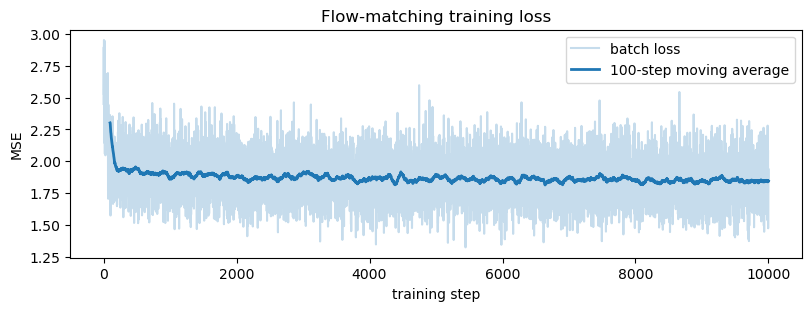

In [19]:
losses_array = np.asarray(losses)
window = 100
smoothed_losses = np.convolve(losses_array, np.ones(window) / window, mode="valid")

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.plot(losses_array, alpha=0.25, color="tab:blue", label="batch loss")
ax.plot(
    np.arange(window - 1, len(losses_array)),
    smoothed_losses,
    color="tab:blue",
    linewidth=2,
    label=f"{window}-step moving average",
)
ax.set(xlabel="training step", ylabel="MSE", title="Flow-matching training loss")
ax.legend();

## 4. Generate samples with Euler integration

Start from fresh Gaussian noise and solve the learned ordinary differential equation $dx/dt=v_\theta(x,t)$. With a uniform grid, one Euler step is

$$x_{t+\Delta t}=x_t + \Delta t\,v_\theta(x_t,t).$$

In [ ]:
@torch.inference_mode()
def sample_flow(model, n_samples, n_steps=50):
    model.eval()
    x_t = torch.randn(n_samples, 1, device=DEVICE)
    time_grid = torch.linspace(0.0, 1.0, n_steps + 1, device=DEVICE)
    for index in range(n_steps):
        t = time_grid[index].expand_as(x_t)
        dt = time_grid[index + 1] - time_grid[index]
        x_t = x_t + dt * model(x_t, t)
    return x_t.squeeze(-1).cpu().numpy()


N_EVAL_SAMPLES = 20000
generated_samples = sample_flow(model, N_EVAL_SAMPLES, n_steps=50)
evaluation_rng = np.random.default_rng(2026)
target_samples = sample_mixture(N_EVAL_SAMPLES, evaluation_rng)

quantiles = np.linspace(0.01, 0.99, 99)
quantile_mae = np.mean(
    np.abs(np.quantile(generated_samples, quantiles) - np.quantile(target_samples, quantiles))
)

assert generated_samples.shape == (N_EVAL_SAMPLES,)
assert np.isfinite(losses_array).all() and np.isfinite(generated_samples).all()
assert quantile_mae < 0.1, f"Quantile MAE is unexpectedly high: {quantile_mae:.4f}"

print(f"Quantile MAE: {quantile_mae:.4f}")
print(f"Generated mean/std: {generated_samples.mean():.4f} / {generated_samples.std():.4f}")
print(f"Target mean/std:    {target_samples.mean():.4f} / {target_samples.std():.4f}")

Quantile MAE: 0.0315
Generated mean/std: 0.2201 / 1.2948
Target mean/std:    0.2108 / 1.2734


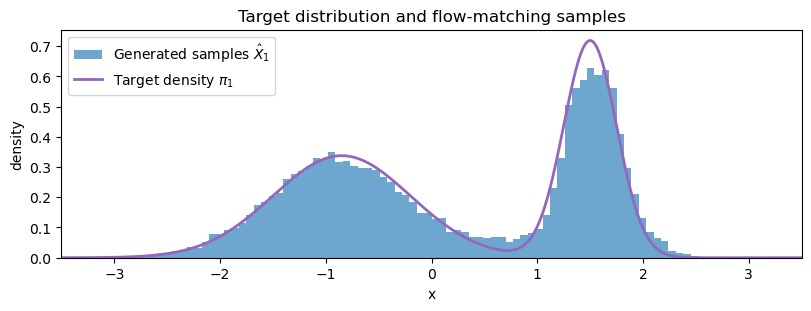

In [21]:
fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.hist(
    generated_samples,
    bins=100,
    range=(-3.5, 3.5),
    density=True,
    alpha=0.65,
    color="tab:blue",
    label=r"Generated samples $\hat{X}_1$",
)
ax.plot(
    x_grid,
    mixture_pdf(x_grid),
    color="tab:purple",
    linewidth=2,
    label=r"Target density $\pi_1$",
)
ax.set(
    xlim=(-3.5, 3.5),
    xlabel="x",
    ylabel="density",
    title="Target distribution and flow-matching samples",
)
ax.legend();